In [1]:
import pandas as pd
import numpy as np
import altair as alt
import matplotlib.pyplot as plt

In [2]:
owid = pd.read_csv("owid-covid-data.csv")
owid["date"] = pd.to_datetime(owid["date"])

In [3]:
selected_countries = [
    "United States", "China", "New Zealand", "Sweden", "Brazil", "Germany",
    "United Kingdom", "France", "Italy", "Spain",
    "Canada", "Australia", "Japan", "South Korea", "Singapore",
    "Netherlands", "Belgium", "Denmark", "Norway"
]
owid_filter = owid[owid['location'].isin(selected_countries)].copy()

owid_filter = owid_filter[~owid_filter['iso_code'].str.startswith('OWID')]

owid_filter["week"] = owid_filter["date"].dt.to_period("W").dt.start_time
owid_filter = owid_filter.sort_values(["location", "date"])


## average variables:
avg_vars = [
    "new_cases_smoothed_per_million",
    "new_deaths_smoothed_per_million",
    "reproduction_rate",
    "positive_rate",
    "stringency_index",
    "icu_patients_per_million",
    "hosp_patients_per_million",
    "weekly_icu_admissions_per_million"
]

## last value variables
last_vars = [
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred",
    "total_boosters_per_hundred",
    "total_vaccinations_per_hundred"
]

## static:
static_vars = [
    "population_density",
    "median_age",
    "aged_65_older",
    "aged_70_older",
    "gdp_per_capita",
    "extreme_poverty",
    "cardiovasc_death_rate",
    "diabetes_prevalence",
    "female_smokers",
    "male_smokers",
    "handwashing_facilities",
    "hospital_beds_per_thousand",
    "life_expectancy",
    "human_development_index"
]

agg_dict = {}

# Average
for col in avg_vars:
    agg_dict[col] = "mean"

# Last value
for col in last_vars:
    agg_dict[col] = "last"

# Static (just take first value per country)
for col in static_vars:
    agg_dict[col] = "first"

weeklyowid_df = (
    owid_filter
    .groupby(["location", "week"])
    .agg(agg_dict)
    .reset_index()
)

weeklyowid_df = weeklyowid_df.rename(columns={"location": "country"})

In [4]:
weeklyowid_df = weeklyowid_df.sort_values(["country", "week"])
weeklyowid_df[avg_vars + last_vars] = (
    weeklyowid_df.groupby("country")[avg_vars + last_vars].ffill()
)

In [5]:
weeklyowid_df = weeklyowid_df.dropna(subset=["new_deaths_smoothed_per_million"])
weeklyowid_df["stringency_lag_2"] = weeklyowid_df.groupby("country")["stringency_index"].shift(2)
weeklyowid_df["stringency_lag_3"] = weeklyowid_df.groupby("country")["stringency_index"].shift(3)
weeklyowid_df["stringency_lag_4"] = weeklyowid_df.groupby("country")["stringency_index"].shift(4)

In [6]:
weeklyowid_df.columns
(weeklyowid_df.isna().mean() * 100).round(2)

country                                  0.00
week                                     0.00
new_cases_smoothed_per_million           0.00
new_deaths_smoothed_per_million          0.00
reproduction_rate                        3.21
positive_rate                           17.06
stringency_index                         0.00
icu_patients_per_million                31.26
hosp_patients_per_million               33.48
weekly_icu_admissions_per_million       68.57
people_vaccinated_per_hundred           22.25
people_fully_vaccinated_per_hundred     23.09
total_boosters_per_hundred              33.39
total_vaccinations_per_hundred          21.70
population_density                       0.00
median_age                               0.00
aged_65_older                            0.00
aged_70_older                            0.00
gdp_per_capita                           0.00
extreme_poverty                         31.59
cardiovasc_death_rate                    0.00
diabetes_prevalence               

In [7]:
# Make a copy
model_df = weeklyowid_df.copy()

# Sort first
model_df = model_df.sort_values(["country", "week"])

# 1. Drop variables with too much missingness / weaker value
drop_cols = [
    "handwashing_facilities",
    "icu_patients_per_million",
    "hosp_patients_per_million",
    "extreme_poverty"
]

model_df = model_df.drop(columns=drop_cols, errors="ignore")

# 2. Forward fill important time-series variables within each country
fill_cols = [
    "reproduction_rate",
    "positive_rate",
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred",
    "total_vaccinations_per_hundred",
    "total_boosters_per_hundred",
    "stringency_index"
]

fill_cols = [col for col in fill_cols if col in model_df.columns]

model_df[fill_cols] = (
    model_df.groupby("country")[fill_cols].ffill()
)

# 3. Recreate lag variables after sorting/filling
model_df["stringency_lag_2"] = model_df.groupby("country")["stringency_index"].shift(2)
model_df["stringency_lag_3"] = model_df.groupby("country")["stringency_index"].shift(3)
model_df["stringency_lag_4"] = model_df.groupby("country")["stringency_index"].shift(4)

# 4. Drop rows missing target
model_df = model_df.dropna(subset=["new_deaths_smoothed_per_million"])

# 5. Optional: keep only columns you want for modeling
model_vars = [
    "country",
    "week",
    "new_deaths_smoothed_per_million",
    "new_cases_smoothed_per_million",
    "reproduction_rate",
    "positive_rate",
    "stringency_index",
    "stringency_lag_2",
    "stringency_lag_3",
    "stringency_lag_4",
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred",
    "total_vaccinations_per_hundred",
    "total_boosters_per_hundred",
    "population_density",
    "median_age",
    "aged_65_older",
    "aged_70_older",
    "gdp_per_capita",
    "cardiovasc_death_rate",
    "diabetes_prevalence",
    "female_smokers",
    "male_smokers",
    "hospital_beds_per_thousand",
    "life_expectancy",
    "human_development_index"
]

model_vars = [col for col in model_vars if col in model_df.columns]
model_df = model_df[model_vars]

# 6. Check remaining missingness
missing_summary = pd.DataFrame({
    "Missing Count": model_df.isna().sum(),
    "Missing %": model_df.isna().mean() * 100
}).sort_values(by="Missing %", ascending=False)

print(model_df.shape)
display(missing_summary)
display(model_df.head())

(4543, 26)


,Missing Count,Missing %
total_boosters_per_hundred,1517,33.392032
people_fully_vaccinated_per_hundred,1049,23.090469
people_vaccinated_per_hundred,1011,22.254017
total_vaccinations_per_hundred,986,21.703720
positive_rate,775,17.059212
reproduction_rate,146,3.213735
stringency_lag_4,76,1.672903
stringency_lag_3,57,1.254678
stringency_lag_2,38,0.836452
country,0,0.000000


,country,week,new_deaths_smoothed_per_million,new_cases_smoothed_per_million,reproduction_rate,positive_rate,stringency_index,stringency_lag_2,stringency_lag_3,stringency_lag_4,...,aged_65_older,aged_70_older,gdp_per_capita,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,hospital_beds_per_thousand,life_expectancy,human_development_index
1,Australia,2020-01-06,0.0,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
2,Australia,2020-01-13,0.0,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
3,Australia,2020-01-20,0.0,0.002857,NaN,NaN,1.588571,0.000000,NaN,NaN,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
4,Australia,2020-01-27,0.0,0.022857,NaN,NaN,7.940000,0.000000,0.0,NaN,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
5,Australia,2020-02-03,0.0,0.037143,NaN,NaN,19.440000,1.588571,0.0,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94


In [8]:
model_df = model_df.drop(columns=["positive_rate"], errors="ignore")
vax_cols = [
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred",
    "total_vaccinations_per_hundred",
    "total_boosters_per_hundred"
]

# Only keep columns that exist (safe)
vax_cols = [col for col in vax_cols if col in model_df.columns]

model_df[vax_cols] = model_df[vax_cols].fillna(0)
model_df.head(20)

,country,week,new_deaths_smoothed_per_million,new_cases_smoothed_per_million,reproduction_rate,stringency_index,stringency_lag_2,stringency_lag_3,stringency_lag_4,people_vaccinated_per_hundred,...,aged_65_older,aged_70_older,gdp_per_capita,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,hospital_beds_per_thousand,life_expectancy,human_development_index
1,Australia,2020-01-06,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
2,Australia,2020-01-13,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
3,Australia,2020-01-20,0.000000,0.002857,NaN,1.588571,0.000000,NaN,NaN,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
4,Australia,2020-01-27,0.000000,0.022857,NaN,7.940000,0.000000,0.000000,NaN,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
5,Australia,2020-02-03,0.000000,0.037143,NaN,19.440000,1.588571,0.000000,0.000000,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
6,Australia,2020-02-10,0.000000,0.017143,NaN,19.440000,7.940000,1.588571,0.000000,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
7,Australia,2020-02-17,0.000000,0.005714,NaN,19.440000,19.440000,7.940000,1.588571,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
8,Australia,2020-02-24,0.000000,0.037143,NaN,19.440000,19.440000,19.440000,7.940000,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
9,Australia,2020-03-02,0.002857,0.051429,NaN,19.440000,19.440000,19.440000,19.440000,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
10,Australia,2020-03-09,0.020000,0.345714,2.270000,19.440000,19.440000,19.440000,19.440000,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94


In [9]:
(model_df.isna().mean() * 100).round(2)

country                                0.00
week                                   0.00
new_deaths_smoothed_per_million        0.00
new_cases_smoothed_per_million         0.00
reproduction_rate                      3.21
stringency_index                       0.00
stringency_lag_2                       0.84
stringency_lag_3                       1.25
stringency_lag_4                       1.67
people_vaccinated_per_hundred          0.00
people_fully_vaccinated_per_hundred    0.00
total_vaccinations_per_hundred         0.00
total_boosters_per_hundred             0.00
population_density                     0.00
median_age                             0.00
aged_65_older                          0.00
aged_70_older                          0.00
gdp_per_capita                         0.00
cardiovasc_death_rate                  0.00
diabetes_prevalence                    0.00
female_smokers                         0.00
male_smokers                           0.00
hospital_beds_per_thousand      

In [10]:
cols_to_drop = [
    "stringency_index",
    "stringency_lag_4",
    "stringency_lag_3",
    "people_fully_vaccinated_per_hundred",
    "total_vaccinations_per_hundred",
    "total_boosters_per_hundred",
    "median_age",
    "aged_70_older", 
    "cardiovasc_death_rate", 
    "female_smokers",
    "male_smokers",
    "gdp_per_capita"
]

model_df = model_df.drop(columns=cols_to_drop, errors="ignore")
final_model_df = model_df.dropna().copy()

In [11]:
y = final_model_df["new_deaths_smoothed_per_million"]

X = final_model_df.drop(columns=[
    "new_deaths_smoothed_per_million",
    "country",
    "week"
])

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_scaled, y)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
0,new_cases_smoothed_per_million,0.583251
2,stringency_lag_2,0.573251
5,aged_65_older,0.369758
9,human_development_index,0.120764
4,population_density,0.018951
1,reproduction_rate,-0.237018
6,diabetes_prevalence,-0.256009
7,hospital_beds_per_thousand,-0.285256
3,people_vaccinated_per_hundred,-0.356149
8,life_expectancy,-0.458140


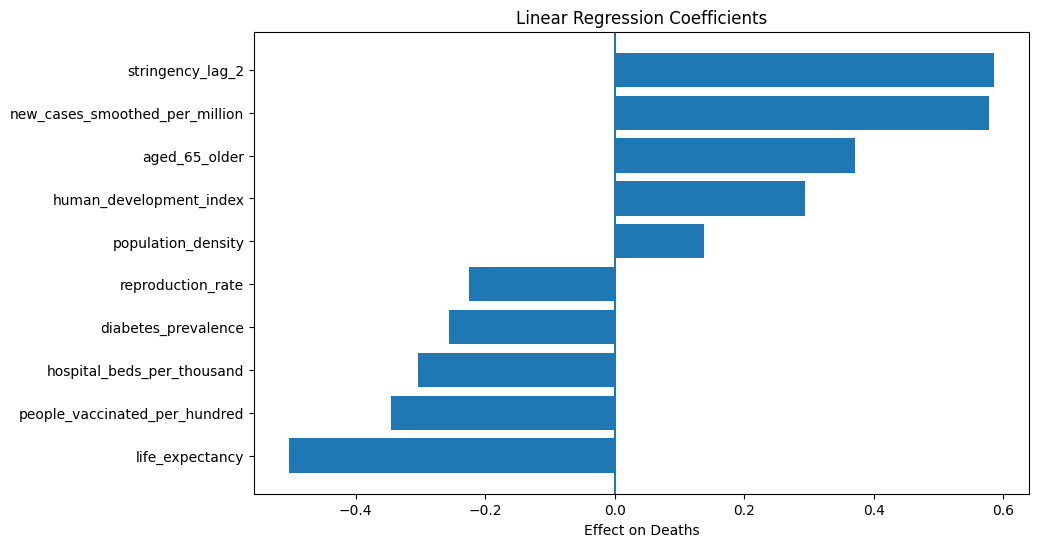

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'Feature': [
        'stringency_lag_2',
        'new_cases_smoothed_per_million',
        'aged_65_older',
        'human_development_index',
        'population_density',
        'reproduction_rate',
        'diabetes_prevalence',
        'hospital_beds_per_thousand',
        'people_vaccinated_per_hundred',
        'life_expectancy'
    ],
    'Coefficient': [
        0.585307,
        0.577344,
        0.370707,
        0.294598,
        0.137943,
        -0.225014,
        -0.255247,
        -0.304151,
        -0.344916,
        -0.502467
    ]
})

coef_df = coef_df.sort_values(by='Coefficient')

plt.figure(figsize=(10,6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.axvline(0)
plt.title("Linear Regression Coefficients")
plt.xlabel("Effect on Deaths")
plt.show()

In [13]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_scaled)

print("R²:", r2_score(y, y_pred))

R²: 0.269137655008285


Train R²: 0.9827864612945271
Test R²: 0.26713677877722686

Feature Importance:
                          Feature  Importance
0  new_cases_smoothed_per_million    0.283889
3   people_vaccinated_per_hundred    0.221784
2                stringency_lag_2    0.190561
1               reproduction_rate    0.102818
6             diabetes_prevalence    0.082156
5                   aged_65_older    0.034214
4              population_density    0.027552
9         human_development_index    0.020808
8                 life_expectancy    0.018654
7      hospital_beds_per_thousand    0.017565


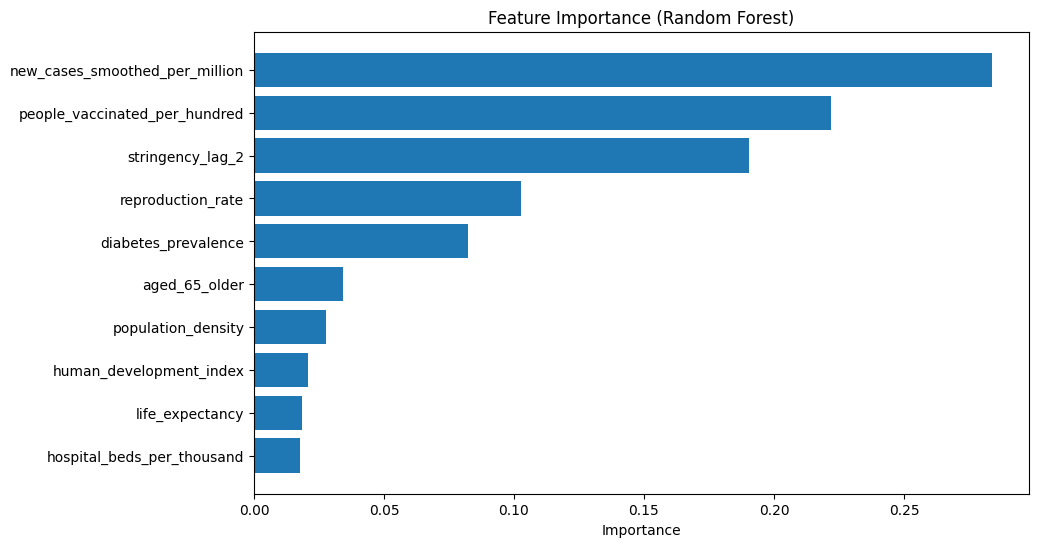

In [14]:
# ===============================
# TIME-BASED TRAIN / TEST SPLIT + RANDOM FOREST
# ===============================

import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Sort data by country and time
final_model_df = final_model_df.sort_values(["country", "week"])

# 2. Create time-based split (80% train, 20% test)
split_date = final_model_df["week"].quantile(0.8)

train_df = final_model_df[final_model_df["week"] <= split_date]
test_df  = final_model_df[final_model_df["week"] > split_date]

# 3. Define features (X) and target (y)
X_train = train_df.drop(columns=["new_deaths_smoothed_per_million", "country", "week"])
y_train = train_df["new_deaths_smoothed_per_million"]

X_test = test_df.drop(columns=["new_deaths_smoothed_per_million", "country", "week"])
y_test = test_df["new_deaths_smoothed_per_million"]

# 4. Initialize Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# 5. Train model
rf_model.fit(X_train, y_train)

# 6. Predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# 7. Evaluate performance
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred_test))

# 8. Feature Importance
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(rf_importance)

# 9. (Optional) Plot feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(rf_importance["Feature"], rf_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [15]:
## reproduction rate: On average, how many people one infected person spreads the virus to at a given time